# 电梯IoT故障检测

## 任务1 正常运行曲线绘图

### 1.1 数据处理器与绘图器定义

In [3]:
import pandas as pd
import os
import numpy as np
from scipy.signal import butter, filtfilt
import pandas as pd
import matplotlib.pyplot as plt  # 补充缺失的导入
import logging
# 设置 matplotlib 的字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 配置日志记录
logging.basicConfig(
    filename='data_processing.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w'
)
def log_print(message):
    """将信息同时输出到日志文件和控制台"""
    print(message)
    logging.info(message)
# 读取采集数据并进行滤波，积分处理
class DataProcessor:
    time_col:str
    def __init__(self):
        # pass
        self.file_contents = []
        # 记录每个文件已完成的处理步骤
        self.processed_status = {} 
        self.time_col = 'time_sec'
        # 初始化速度和位移列名
        self.ax_col = 'AX'
        self.ay_col = 'AY'
        self.vx_col = 'VX'
        self.vy_col = 'VY'
        self.dx_col = 'DX'
        self.dy_col = 'DY'
        # 新增列名，用于存储新积分策略的结果
        self.vy_new_col = 'VY_new'
        self.dy_new_col = 'DY_new'
        # 定义重力加速度常量
        # self.GRAVITY = 0.9806650
        self.GRAVITY = 0
    def add_file(self,file_path):
        
        if os.path.isdir(file_path):
            for root, _, files in os.walk(file_path):
                for file in files:
                    if file.endswith('.xlsx') or file.endswith('.xls'):
                        full_path = os.path.join(root, file)
                        try:
                            content = pd.read_excel(full_path)
                            self.file_contents.append({'filename': file, 'content': content})
                            if file not in self.processed_status:
                                self.processed_status[file] = {
                                    'date_time_tran': False, 
                                    'clean_data': False, 
                                    'add_time_column': False, 
                                    'calc_velocity_and_displacement': False,
                                    'calc_velocity_and_displacement_new': False,  # 新增处理步骤
                                    'exclude_gravity':False,
                                    'filtered':False,
                                    'subtract_pause_mean': False  
                                        }
                        except Exception as e:
                            log_print(f"读取文件 {full_path} 时出错: {e}")
        else:
            if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
                try:
                    content = pd.read_excel(file_path)
                    self.file_contents.append({'filename': os.path.basename(file_path), 'content': content})
                    if os.path.basename(file_path) not in self.processed_status:
                        self.processed_status[os.path.basename(file_path)] = {
                            'date_time_tran': False, 
                            'clean_data': False, 
                            'add_time_column': False, 
                            'calc_velocity_and_displacement': False,
                            'calc_velocity_and_displacement_new': False,  # 新增处理步骤
                            'exclude_gravity':False,
                            'filtered':False,
                            'subtract_pause_mean': False 
                                }
                except Exception as e:
                    log_print(f"读取文件 {file_path} 时出错: {e}")
        
    def clean_data(self,df,filename):
        original_length = len(df)  # 记录原始数据长度
        
        # 删除遇到第一个status为“开”之前的字段
        if 'status' in df.columns:
            first_open_index = df[df['status'] == '开'].index.min()
            if pd.notna(first_open_index):
                df = df.loc[first_open_index:]
        
        # 删除最后一个“关”之后的所有字段
        if 'status' in df.columns:
            last_close_index = df[df['status'] == '关'].index.max()
            if pd.notna(last_close_index):
                df = df.loc[:last_close_index]
        
        # 统计并打印删除的字段数量
        deleted_count = original_length - len(df)
        log_print(f"文件{filename}删除了{deleted_count}行数据")
        if 'create_dt' in df.columns:          
            # 删除时间列中的异常值
            df = df.dropna(subset=['create_dt'])
            
        # 检查加速度和角速度列
        accel_columns = ['AX', 'AY', 'AZ']
        gyro_columns = ['GX', 'GY', 'GZ']
        analysis_columns = accel_columns + gyro_columns
        
        # 确保这些列存在
        for col in analysis_columns:
            if col not in df.columns:
                log_print(f"对暂停状态的参数进行统计时，发现文件{filename}列{col}缺失")
                # 如果缺少某些列，创建它们并填充为0
                df[col] = 0.0
        
        # 对电梯暂停时的参数进行统计分析
        pause_stats = pd.DataFrame()
        if 'status' in df.columns:
            open_indices = df[df['status'] == '开'].index
            close_indices = df[df['status'] == '关'].index
            
            # 找到每一对“开”和“关”的区间
            for open_idx in open_indices:
                next_close_idx = close_indices[close_indices > open_idx].min()
                if pd.notna(next_close_idx):
                    pause_data = df.loc[open_idx:next_close_idx]
                    pause_stats = pd.concat([pause_stats, pause_data])
        
        # 删除加速度和角速度列的异常值
        df = df.dropna(subset=analysis_columns)
        
        # 返回处理后的数据和统计结果
        return df, pause_stats
    # def data_process_with_flat_curve(self):
        
    #     for item in self.file_contents:
    #         filename = item['filename']
    #         if "flat_curve" not in self.processed_status[filename].columns:
    #             self.processed_status[filename]["flat_curve"] = False
    #             # 进行曲线平滑处理
    #             item['content'] = self.fil(item['content'])
    #             self.processed_status[filename]["flat_curve"] = True
    #         elif self.processed_status[filename]["flat_curve"]:
    #             print(f"文件{filename}已进行曲线平滑处理过")
    # def flat_curve(self,df):
    #     # 对加速度和角速度列进行曲线平滑处理
    #     for col in ['AX', 'AY', 'AZ', 'GX', 'GY', 'GZ']:
    #         df[col] = df[col].rolling(window=2, min_periods=1).mean()
    #     return df
        
    def data_process(self):
        if not self.file_contents:
            log_print("没有文件内容可处理")
            return
        # 定义处理步骤映射
        process_steps = {
            'date_time_tran': {
                'method': self.date_time_tran,
                'error_msg': "日期数据处理过程中出错"
            },
            'clean_data': {
                'method': lambda item: self.clean_data(item['content'], item['filename']),
                'error_msg': "数据清洁过程中出错",
                'update_content': True
            },
            'add_time_column': {
                'method': self.add_time_column,
                'error_msg': "添加时间列过程中出错"
            },
            'calc_velocity_and_displacement': {
                'method': self.calc_velocity_and_displacement,
                'error_msg': "计算速度和位移过程中出错"
            }
        }
        # 遍历每个处理步骤
        for step_name, step_info in process_steps.items():
            if step_name == 'calc_velocity_and_displacement':
                continue
            try:
                if any(not self.processed_status[item['filename']][step_name] for item in self.file_contents):
                    if step_info.get('update_content'):
                        for item in self.file_contents:
                            if not self.processed_status[item['filename']][step_name]:
                                log_print(f"{item['filename']}文件正在进行{step_name}处理")
                                item['content'],item['pause_status'] = step_info['method'](item)
                                self.processed_status[item['filename']][step_name] = True
                            else:
                                log_print(f"{item['filename']}文件已经进行{step_name}处理")
                    else:
                        log_print(f"执行{step_name}处理")
                        step_info['method']()
                        for item in self.file_contents:
                            if not self.processed_status[item['filename']][step_name]:
                                log_print(f"{item['filename']}文件正在进行{step_name}处理")
                                self.processed_status[item['filename']][step_name] = True
                            else:
                                log_print(f"{item['filename']}文件已经进行{step_name}处理")
            except Exception as e:
                log_print(f"{step_info['error_msg']}: {e}")
        # for file_data in self.file_contents:
        #     if self.processed_status[file_data['filename']]['exclude_gravity']:
        #         log_print(f"{file_data['filename']}文件已经进行exclude_gravity处理")
        #         continue
        #     log_print(f"{file_data['filename']}文件正在进行exclude_gravity处理")
        #     df = file_data['content']
        #     # 减去重力加速度对Y轴加速度的影响
        #     df['AY'] = df['AY'] - self.GRAVITY
        #     file_data['content'] = df
        #     self.processed_status[file_data['filename']]['exclude_gravity'] = True
    def data_process_with_filter_without_minus_means(self):
        self.data_process()
        for item in self.file_contents:
            if not self.processed_status[item['filename']]['filtered']:
                log_print(f"{item['filename']}文件正在进行filtered处理")
                self.filter_data(item)
                self.processed_status[item['filename']]['filtered'] = True
            else:
                log_print(f"{item['filename']}文件已经进行filtered处理")

    def data_process_with_filter(self):
        self.data_process()
        for item in self.file_contents:
            if not self.processed_status[item['filename']]['filtered']:
                log_print(f"{item['filename']}文件正在进行filtered处理")
                self.filter_data(item)
                self.processed_status[item['filename']]['filtered'] = True
            else:
                log_print(f"{item['filename']}文件已经进行filtered处理")
        # 减去电梯暂停时数据的均值
        for item in self.file_contents:
            if not self.processed_status[item['filename']]['subtract_pause_mean']:
                try:
                    log_print(f"{item['filename']}文件正在进行subtract_pause_mean处理")
                    df = item['content']
                    if 'pause_status' in item:
                        pause_stats = item['pause_status']
                        if not pause_stats.empty:
                            # 仅对 AY 减去暂停时的均值
                            if 'AY' in df.columns:
                                df['AY'] -= pause_stats['AY'].mean()
                    
                    # 对 AX 减去非暂停时的均值
                    if 'AX' in df.columns and 'pause_status' in item and not item['pause_status'].empty:
                        # 获取暂停状态的索引
                        pause_indices = item['pause_status'].index
                        # 获取非暂停状态的数据
                        non_pause_data = df.drop(pause_indices)
                        # 计算非暂停状态下 AX 的均值
                        non_pause_mean = non_pause_data['AX'].mean()
                        df['AX'] -= non_pause_mean
                    elif 'AX' in df.columns:
                        # 如果没有暂停数据，直接使用全部数据的均值
                        df['AX'] -= df['AX'].mean()
                    item['content'] = df
                    self.processed_status[item['filename']]['subtract_pause_mean'] = True
                except Exception as e:
                    log_print(f"减去电梯暂停时数据均值过程中出错: {e}")
            else:
                log_print(f"{item['filename']}文件已经进行subtract_pause_mean处理")
                
    def filter_data(self,item):
        # 定义截止频率和采样频率
        cutoff_freq = 1  # 截止频率，单位Hz
        sampling_freq = 5  # 采样频率，单位Hz
        order = 2  # 滤波器阶数
        # 计算归一化截止频率
        nyquist_freq = 0.5 * sampling_freq
        normalized_cutoff = cutoff_freq / nyquist_freq
        # 设计二阶巴特沃斯滤波器
        b, a = butter(N=order, Wn=normalized_cutoff, btype='low', analog=False)
        # 对每个文件中的加速度和角速度数据进行滤波
        accel_columns = ['AX', 'AY', 'AZ']
        gyro_columns = ['GX', 'GY', 'GZ']
        df = item['content']
        for col in accel_columns + gyro_columns:
            if col in df.columns:
                df[col] = filtfilt(b, a, df[col])
        item['content'] = df
            
    def date_time_tran(self):
        for item in self.file_contents:
            if 'create_dt' in item['content'].columns:
                item['content']['create_dt'] = pd.to_datetime(item['content']['create_dt'], format=r'%Y-%m-%d %H:%M:%S')
                # 去掉日期部分，只保留时间
                item['content']['create_dt'] = item['content']['create_dt'].dt.time
            else:
                log_print(f"列表{item['filename']}中不存在create_dt列")    
    def add_time_column(self):
        """
        为每个文件的数据添加一个新的时间列，以秒为单位，第一个数据是0秒，第二个是0.2秒，第三是0.4秒，以此类推
        """
        for item in self.file_contents:
            df = item['content']
            df['time_sec'] = [i * 0.2 for i in range(len(df))]
            item['content'] = df
    def calc_velocity_and_displacement(self):
        """
        根据AX，AY计算并添加对应的X轴速度，Y轴速度；X轴位移，Y轴位移列
        对于X轴，在电梯非暂停状态，认为加速度是0；对于Y轴，在电梯暂停状态，认为加速度是0
        """
        for item in self.file_contents:
            df = item['content']
            if 'AX' in df.columns and 'AY' in df.columns and 'status' in df.columns:
                log_print(f"{item['filename']}文件正在进行calc_velocity_and_displacement处理")
                # 初始化速度和位移列
                df[self.vx_col] = 0.0
                df[self.vy_col] = 0.0
                df[self.dx_col] = 0.0
                df[self.dy_col] = 0.0
                # 计算时间间隔
                dt = df[self.time_col].diff()
                dt.iloc[0] = 0.2  # 第一个时间间隔设为0.2秒
                # 创建暂停状态掩码
                open_indices = df[df['status'] == '开'].index
                close_indices = df[df['status'] == '关'].index
                pause_mask = pd.Series(False, index=df.index)
                for open_idx in open_indices:
                    next_close_idx = close_indices[close_indices > open_idx].min()
                    if pd.notna(next_close_idx):
                        pause_mask.loc[open_idx:next_close_idx] = True
                # 创建X轴和Y轴加速度序列
                ax = df['AX'].copy()
                ay = df['AY'].copy()
                # 对于X轴，在非暂停状态加速度设为0
                ax[~pause_mask] = 0
                # 对于Y轴，在暂停状态加速度设为0
                ay[pause_mask] = 0

                # 初始化速度和位移序列
                vx = pd.Series(0.0, index=df.index)
                vy = pd.Series(0.0, index=df.index)
                dx = pd.Series(0.0, index=df.index)
                dy = pd.Series(0.0, index=df.index)

                # 找到所有暂停和非暂停区间
                intervals = []
                prev_mask = pause_mask.iloc[0]
                start_idx = df.index[0]
                for idx in df.index[1:]:
                    current_mask = pause_mask.loc[idx]
                    if current_mask != prev_mask:
                        intervals.append((start_idx, idx - 1, prev_mask))
                        start_idx = idx
                        prev_mask = current_mask
                intervals.append((start_idx, df.index[-1], prev_mask))

                # 处理每个区间
                for start, end, is_pause in intervals:
                    interval_slice = slice(start, end)
                    interval_dt = dt.loc[interval_slice]
                    # 计算X轴速度
                    if is_pause:
                        interval_ax = ax.loc[interval_slice]
                        vx.loc[interval_slice] = (interval_ax * interval_dt).cumsum()
                        # 计算X轴位移
                        interval_vx = vx.loc[interval_slice]
                        dx.loc[interval_slice] = (interval_vx * interval_dt).cumsum()
                    else:
                        # 非暂停状态X轴位移归零
                        dx.loc[interval_slice] = 0
                    # 计算Y轴速度
                    interval_ay = ay.loc[interval_slice]
                    vy.loc[interval_slice] = (interval_ay * interval_dt).cumsum()


                    # 计算Y轴位移
                    if is_pause:
                        # 暂停状态Y轴位移保持进入暂停状态的值
                        if start > df.index[0]:
                            dy.loc[interval_slice] = dy.loc[start - 1]
                    else:
                        # 非暂停状态Y轴位移从进入非暂停状态的值开始积分
                        if start > df.index[0]:
                            prev_dy = dy.loc[start - 1]
                        else:
                            prev_dy = 0
                        interval_vy = vy.loc[interval_slice]
                        dy.loc[interval_slice] = prev_dy + (interval_vy * interval_dt).cumsum()

                df[self.vx_col] = vx
                df[self.vy_col] = vy
                df[self.dx_col] = dx
                df[self.dy_col] = dy
                item['content'] = df
                self.processed_status[item['filename']]['calc_velocity_and_displacement'] = True
            elif 'status' not in df.columns:
                log_print(f"文件{item['filename']}缺少status列，无法确定暂停状态，无法计算速度和位移")
            else:
                log_print(f"文件{item['filename']}缺少AX或AY列，无法计算速度和位移")
    def calc_velocity_and_displacement_new(self):
        """
        采用另一种积分策略，对于X轴，在电梯非暂停状态，不抹零加速度；
        对于Y轴，在电梯暂停状态，认为加速度是0；
        积分得到Y轴速度后，将Y轴速度在暂停状态的速度抹为0，再积分得到Y轴位移
        """        
        for item in self.file_contents:
            df = item['content']
            if 'AX' in df.columns and 'AY' in df.columns and 'status' in df.columns:
                log_print(f"{item['filename']}文件正在进行calc_velocity_and_displacement_new处理")
                # 初始化新的Y轴速度和位移列
                df[self.vy_new_col] = 0.0
                df[self.dy_new_col] = 0.0
                # 初始化X轴速度和位移列
                df[self.vx_col] = 0.0
                df[self.dx_col] = 0.0
                # 计算时间间隔
                dt = df[self.time_col].diff()
                dt.iloc[0] = 0.2  # 第一个时间间隔设为0.2秒
                # 创建暂停状态掩码
                open_indices = df[df['status'] == '开'].index
                close_indices = df[df['status'] == '关'].index
                pause_mask = pd.Series(False, index=df.index)
                for open_idx in open_indices:
                    next_close_idx = close_indices[close_indices > open_idx].min()
                    if pd.notna(next_close_idx):
                        pause_mask.loc[open_idx:next_close_idx] = True
                # 创建X轴和Y轴加速度序列
                ax = df['AX'].copy()
                ay = df['AY'].copy()
                # 对于X轴，不抹零加速度
                # 对于Y轴，在暂停状态加速度设为0
                ay[pause_mask] = 0

                # 初始化速度和位移序列
                vx = pd.Series(0.0, index=df.index)
                vy = pd.Series(0.0, index=df.index)
                dx = pd.Series(0.0, index=df.index)
                dy = pd.Series(0.0, index=df.index)

                # 找到所有暂停和非暂停区间
                intervals = []
                prev_mask = pause_mask.iloc[0]
                start_idx = df.index[0]
                for idx in df.index[1:]:
                    current_mask = pause_mask.loc[idx]
                    if current_mask != prev_mask:
                        intervals.append((start_idx, idx - 1, prev_mask))
                        start_idx = idx
                        prev_mask = current_mask
                intervals.append((start_idx, df.index[-1], prev_mask))

                # 处理每个区间
                for start, end, is_pause in intervals:
                    interval_slice = slice(start, end)
                    interval_dt = dt.loc[interval_slice]
                    # 计算X轴速度
                    interval_ax = ax.loc[interval_slice]
                    vx.loc[interval_slice] = (interval_ax * interval_dt).cumsum()

                    # 计算X轴位移
                    if is_pause:
                        interval_vx = vx.loc[interval_slice]
                        dx.loc[interval_slice] = (interval_vx * interval_dt).cumsum()
                    else:
                        # 非暂停状态X轴位移归零
                        dx.loc[interval_slice] = 0

                    # 计算Y轴速度
                    interval_ay = ay.loc[interval_slice]
                    vy.loc[interval_slice] = (interval_ay * interval_dt).cumsum()

                    # 计算Y轴位移
                    if is_pause:
                        # 暂停状态Y轴位移保持进入暂停状态的值
                        if start > df.index[0]:
                            dy.loc[interval_slice] = dy.loc[start - 1]
                    else:
                        # 非暂停状态Y轴位移从进入非暂停状态的值开始积分
                        if start > df.index[0]:
                            prev_dy = dy.loc[start - 1]
                        else:
                            prev_dy = 0
                        interval_vy = vy.loc[interval_slice]
                        dy.loc[interval_slice] = prev_dy + (interval_vy * interval_dt).cumsum()

                df[self.vx_col] = vx
                df[self.vy_col] = vy
                df[self.dx_col] = dx
                df[self.dy_col] = dy
                item['content'] = df
                self.processed_status[item['filename']]['calc_velocity_and_displacement_new'] = True
            elif 'status' not in df.columns:
                log_print(f"文件{item['filename']}缺少status列，无法确定暂停状态，无法使用新策略计算速度和位移")
            else:
                log_print(f"文件{item['filename']}缺少AX或AY列，无法使用新策略计算速度和位移")
    @property
    def data(self):
        return self.file_contents

class Ploter:
    exclude_cols: list = None
    # 定义需要绘制的特定列，使用 processor 中的成员变量名
    def __init__(self,data_processor):
        self.exclude_cols = ['tag',"status"]
        self.dataprocessor =  data_processor
        self.target_col_map = {
            'X轴加速度': self.dataprocessor.ax_col,
            'X轴速度': self.dataprocessor.vx_col,
            'X轴位移': self.dataprocessor.dx_col,
            'Y轴加速度': self.dataprocessor.ay_col,
            'Y轴速度': self.dataprocessor.vy_col,
            'Y轴位移': self.dataprocessor.dy_col
        }


    def plot_curves(self, save_folder='./normal_plots'):
        """
        对每个文件单独进行正常运行曲线绘制（X轴加速度、X轴速度、X轴位移； Y轴加速度、Y轴速度、Y轴位移），
        并对每个文件保存对应最终结果
        :param save_folder: 保存图片的文件夹路径，默认为 './normal_plots'
        """
        # 确保保存文件夹存在
        os.makedirs(save_folder, exist_ok=True)
        

        # 获取所有文件数据
        file_contents = self.dataprocessor.data
        
        for item in file_contents:
            filename = item['filename']
            df = item['content']
            time_col = self.dataprocessor.time_col
            
            # 筛选出目标列
            value_cols = []
            display_names = []
            for display_name, col in self.target_col_map.items():
                if col in df.columns:
                    value_cols.append(col)
                    display_names.append(display_name)
            num_plots = len(value_cols)
            #
            fig, axes = plt.subplots(num_plots, 1, figsize=(10, 6 * num_plots))
            if num_plots == 1:
                axes = [axes]  # 确保axes始终是列表形式
            
            # 遍历目标列，在不同子图上绘制曲线
            for i, (col, display_name) in enumerate(zip(value_cols, display_names)):
                # plot_data = df[col]
                # 如果是加速度列，将数据乘10转换为 m/s² 单位
                if '加速度' in display_name:
                    plot_data = df[col] * 10
                    axes[i].set_ylabel('数值 (m/s²)')
                elif '速度' in display_name:
                    plot_data = df[col] * 10
                    axes[i].set_ylabel('数值 (m/s)')
                elif '位移' in display_name:
                    plot_data = df[col] * 10
                    axes[i].set_ylabel('数值 (m)')
                else:
                    plot_data = df[col]
                    axes[i].set_ylabel('数值')
                axes[i].plot(df[time_col], plot_data, label=display_name)
                axes[i].set_xlabel('时间')
                axes[i].set_title(f'{filename} - {display_name} 时间序列曲线')
                axes[i].legend()
                axes[i].grid(True)

                # 如果是Y轴位移图，在status为“开”或“关”且floor列存在的点标注楼层
                if display_name == 'Y轴位移' and 'floor' in df.columns and 'status' in df.columns:
                    floor_points = df[(df['status'].isin(['开'])) & df['floor'].notna()]
                    for idx, row in floor_points.iterrows():
                        axes[i].annotate(
                            str(row['floor']),
                            xy=(row[time_col], row[col] * 10),
                            xytext=(5, 5),
                            textcoords='offset points',
                            arrowprops=dict(arrowstyle='->')
                        )
            
            plt.tight_layout()
            
            # 保存图片到指定文件夹
            base_name = os.path.splitext(filename)[0]
            save_path = os.path.join(save_folder, f'{base_name}_normal_curves.png')
            plt.savefig(save_path)
            plt.close()  # 关闭当前图形，避免内存泄漏


### 1.2 正常运行曲线绘图

In [ ]:

file_path = "正常数据集"

normal_dataprocessor = DataProcessor()
normal_dataprocessor.add_file(file_path)
normal_dataprocessor.data_process_with_filter()
normal_dataprocessor.calc_velocity_and_displacement()
# normal_datas = normal_dataprocessor.data

normal_ploter = Ploter(normal_dataprocessor)

normal_ploter.plot_curves(r"normal_plots")




执行date_time_tran处理
device001_label_data_202502181136.xlsx文件正在进行date_time_tran处理
device002_label_data_202502191544.xlsx文件正在进行date_time_tran处理
device003_label_data_202502181537.xlsx文件正在进行date_time_tran处理
device004_正常_202502251127_marked.xlsx文件正在进行date_time_tran处理
device005_正常_202502281414_marked.xlsx文件正在进行date_time_tran处理
device006_正常_1_202503031156_marked.xlsx文件正在进行date_time_tran处理
device006_正常_2_202503030920_marked.xlsx文件正在进行date_time_tran处理
device001_label_data_202502181136.xlsx文件正在进行clean_data处理
文件device001_label_data_202502181136.xlsx删除了674行数据
device002_label_data_202502191544.xlsx文件正在进行clean_data处理
文件device002_label_data_202502191544.xlsx删除了144行数据
device003_label_data_202502181537.xlsx文件正在进行clean_data处理
文件device003_label_data_202502181537.xlsx删除了379行数据
device004_正常_202502251127_marked.xlsx文件正在进行clean_data处理
文件device004_正常_202502251127_marked.xlsx删除了419行数据
device005_正常_202502281414_marked.xlsx文件正在进行clean_data处理
文件device005_正常_202502281414_marked.xlsx删除了1839行数据
device006_正常_1_2025030

C:\Users\FlashBlack7\AppData\Local\Temp\ipykernel_13568\960124337.py:550: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\FlashBlack7\AppData\Local\Temp\ipykernel_13568\960124337.py:555: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.savefig(save_path)


### 1.3 测试过滤效果

执行date_time_tran处理
device001_label_data_202502181136.xlsx文件正在进行date_time_tran处理
device002_label_data_202502191544.xlsx文件正在进行date_time_tran处理
device003_label_data_202502181537.xlsx文件正在进行date_time_tran处理
device004_正常_202502251127_marked.xlsx文件正在进行date_time_tran处理
device005_正常_202502281414_marked.xlsx文件正在进行date_time_tran处理
device006_正常_1_202503031156_marked.xlsx文件正在进行date_time_tran处理
device006_正常_2_202503030920_marked.xlsx文件正在进行date_time_tran处理
device001_label_data_202502181136.xlsx文件正在进行clean_data处理
文件device001_label_data_202502181136.xlsx删除了674行数据
device002_label_data_202502191544.xlsx文件正在进行clean_data处理
文件device002_label_data_202502191544.xlsx删除了144行数据
device003_label_data_202502181537.xlsx文件正在进行clean_data处理
文件device003_label_data_202502181537.xlsx删除了379行数据
device004_正常_202502251127_marked.xlsx文件正在进行clean_data处理
文件device004_正常_202502251127_marked.xlsx删除了419行数据
device005_正常_202502281414_marked.xlsx文件正在进行clean_data处理
文件device005_正常_202502281414_marked.xlsx删除了1839行数据
device006_正常_1_2025030

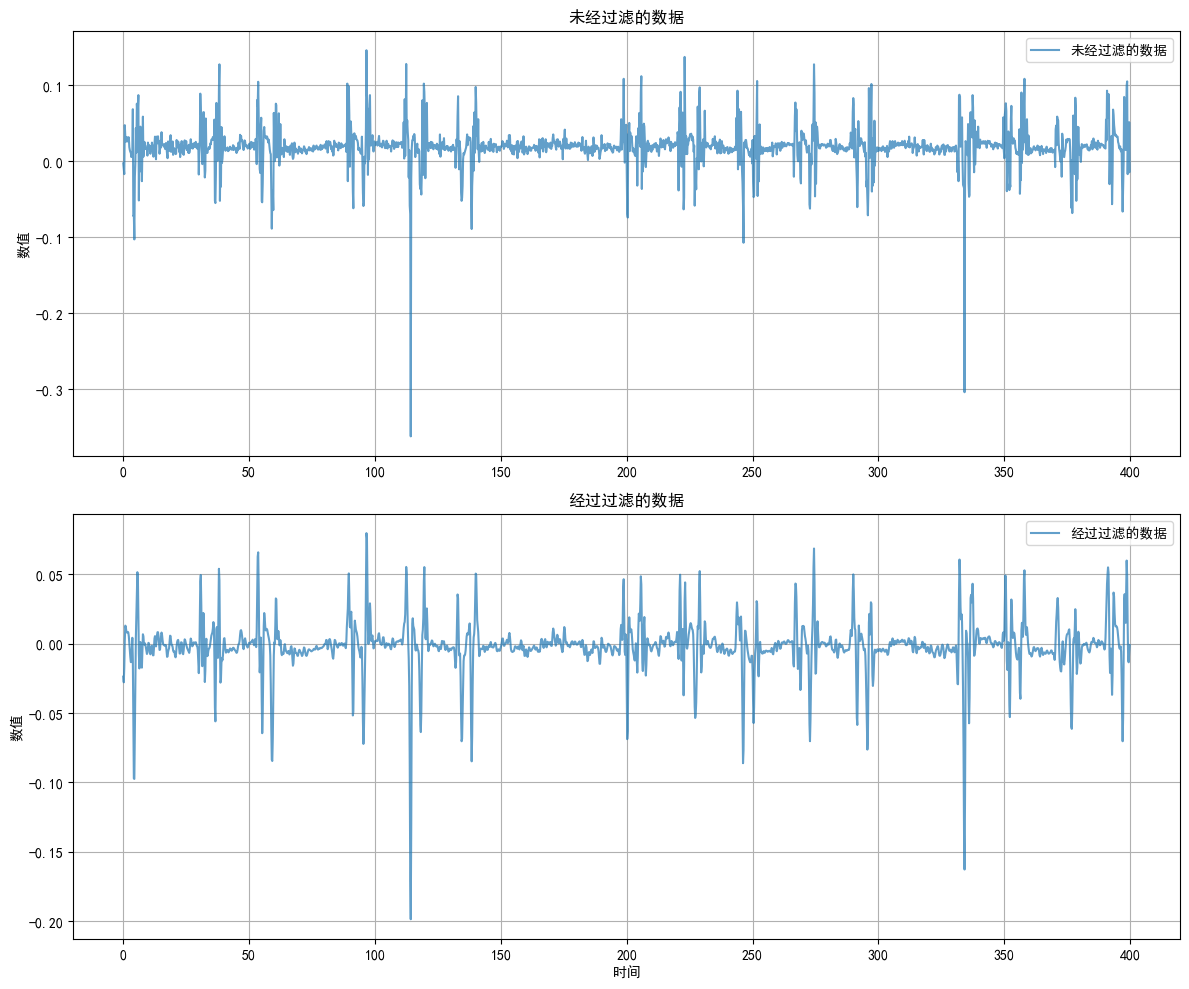

In [22]:
WORK_DIR = r"d:\Flies\工作与学习\实践\工作台\找工作\20250919测试题(8)\20250919测试题\试题1-电梯数据集（已标注）"
# test_file = r"故障数据集\device001_故障_关门不到位_202502201118.xlsx"
file_path = os.path.join(WORK_DIR,"正常数据集")

normal_dataprocessor = DataProcessor()
normal_dataprocessor.add_file(file_path)

normal_dataprocessor.data_process()
normal_dataprocessor.calc_velocity_and_displacement()
data_without_filter = normal_dataprocessor.data[0]['content'].copy()

normal_dataprocessor.data_process_with_filter()
normal_dataprocessor.calc_velocity_and_displacement()
data_with_filter = normal_dataprocessor.data[0]['content'].copy()


# 对比filter前后序列的图像
import matplotlib.pyplot as plt

time_col = 'time_sec'
value_col = 'AX'

# 只取前2000条数据
data_without_filter_head = data_without_filter.head(2000)
data_with_filter_head = data_with_filter.head(2000)

# 创建包含两个子图的画布
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 在第一个子图绘制未经过滤的数据
axes[0].plot(data_without_filter_head[time_col], data_without_filter_head[value_col], label='未经过滤的数据', alpha=0.7)
axes[0].set_title('未经过滤的数据')
axes[0].set_ylabel('数值')
axes[0].legend()
axes[0].grid(True)

# 在第二个子图绘制经过过滤的数据
axes[1].plot(data_with_filter_head[time_col], data_with_filter_head[value_col], label='经过过滤的数据', alpha=0.7)
axes[1].set_title('经过过滤的数据')
axes[1].set_xlabel('时间')
axes[1].set_ylabel('数值')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 任务2 训练模型故障分类

### 2.1 定义特征提取器与特征提取任务步骤

In [11]:

import json
import warnings
import pandas as pd
import os
import numpy as np
from scipy import stats
from scipy.signal import welch
from data_process_and_plot import DataProcessor, log_print
import json
import warnings


# 确保中文显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class FeatureExtractor:
    """特征提取器类，用于从数据中提取时域、频域和非线性动力学特征"""
    
    def __init__(self):
        # 定义要提取特征的列
        self.signal_columns = ['AX', 'AY', 'AZ', 'GX', 'GY', 'GZ']
    
    def normalize(self, data):
        """对数据进行组内归一化（减去均值，除以标准差）"""
        normalized_data = data.copy()
        for col in self.signal_columns:
            if col in normalized_data.columns:
                mean_val = normalized_data[col].mean()
                std_val = normalized_data[col].std()
                if std_val > 0:
                    normalized_data[col] = (normalized_data[col] - mean_val) / std_val
        return normalized_data
    
    def extract_time_domain_features(self, signal):
        """提取时域特征"""
        features = []
        
        # 均值
        features.append(np.mean(signal))
        # 标准差
        features.append(np.std(signal))
        # 均方根（RMS）
        features.append(np.sqrt(np.mean(signal**2)))
        # 峰值
        features.append(np.max(np.abs(signal)))
        # 偏度
        features.append(stats.skew(signal))
        # 峰度
        features.append(stats.kurtosis(signal))
        # 波形因子（RMS除以绝对值的平均值）
        abs_mean = np.mean(np.abs(signal))
        if abs_mean > 0:
            features.append(np.sqrt(np.mean(signal**2)) / abs_mean)
        else:
            features.append(0)

        # 脉冲因子（峰值除以绝对值的平均值）
        if abs_mean > 0:
            features.append(np.max(np.abs(signal)) / abs_mean)
        else:
            features.append(0)
        # 裕度因子（峰值除以RMS）
        rms = np.sqrt(np.mean(signal**2))
        if rms > 0:
            features.append(np.max(np.abs(signal)) / rms)
        else:
            features.append(0)
        # 绝对值的平均值
        features.append(abs_mean)
        
        return features
    
    def extract_frequency_domain_features(self, signal, fs=5):
        """提取频域特征"""
        features = []
        
        # 使用Welch方法计算功率谱密度
        f, Pxx = welch(signal, fs=fs, nperseg=min(1024, len(signal)), noverlap=min(512, len(signal)//2))
        
        # 频谱峰值
        features.append(np.max(Pxx))
        
        # 频谱质心
        if np.sum(Pxx) > 0:
            centroid_freq = np.sum(f * Pxx) / np.sum(Pxx)
        else:
            centroid_freq = 0
        features.append(centroid_freq)
        
        # 均方频率
        if np.sum(Pxx) > 0:
            mean_square_freq = np.sum(f**2 * Pxx) / np.sum(Pxx)
        else:
            mean_square_freq = 0
        features.append(mean_square_freq)
        
        # 频率方差
        if np.sum(Pxx) > 0:
            freq_variance = np.sum((f - centroid_freq)**2 * Pxx) / np.sum(Pxx)
        else:
            freq_variance = 0
        features.append(freq_variance)
        
        # 频谱熵
        if np.sum(Pxx) > 0:
            normalized_Pxx = Pxx / np.sum(Pxx)
            # 修复弃用警告，使用列表推导式并过滤掉可能的非正值
            spectral_entropy = -sum(p * np.log2(p) for p in normalized_Pxx if p > 0)
        else:
            spectral_entropy = 0
        features.append(spectral_entropy)
        
        return features
    
    def spectral_entropy(self, x):
        """计算频谱熵"""
        try:
            # 计算FFT
            fft_values = np.fft.fft(x)
            # 获取频谱幅值的平方作为功率谱
            power_spectrum = np.abs(fft_values[:len(fft_values)//2])**2
            
            # 计算归一化功率谱
            total_power = np.sum(power_spectrum)
            if total_power == 0:
                return 0
            
            probs = power_spectrum / total_power
            
            # 计算熵（修复弃用警告）
            entropy = -sum(p * np.log2(p) for p in probs if p > 0)
            
            # 确保返回有效数值
            return float(entropy) if np.isfinite(entropy) else 0
        except Exception as e:
            log_print(f"计算频谱熵时出错: {e}")
            return 0
            
    def sample_entropy(self, x, m=2, r=0.2):
        """计算样本熵"""
        n = len(x)
        r = r * np.std(x)
        
        def _maxdist(x_i, x_j):
            return np.max(np.abs(x_i - x_j))
        
        def _phi(m_val):
            data = np.array(x)
            C = {}
            for i in range(n - m_val + 1):
                x_i = data[i:i+m_val]
                count = 0
                for j in range(n - m_val + 1):
                    if i != j:
                        x_j = data[j:j+m_val]
                        d = _maxdist(x_i, x_j)
                        if d <= r:
                            count += 1
                if count > 0:
                    C[i] = count
            if len(C) == 0 or (n - m_val + 1) <= 1:
                return 1e-10  # 返回一个很小的值避免除零错误
            return np.sum(list(C.values())) / ((n - m_val + 1) * (n - m_val))
        
        try:
            phi_m = _phi(m)
            phi_m_plus_1 = _phi(m+1)
            if phi_m > 0 and phi_m_plus_1 > 0:
                return -np.log(phi_m_plus_1 / phi_m)
            else:
                return 0
        except Exception as e:
            log_print(f"计算样本熵时出错: {e}")
            return 0
    
    def permutation_entropy(self, x, m=3, delay=1):
        """计算排列熵"""
        n = len(x)
        permutations = []
        
        for i in range(n - m*delay + 1):
            # 取延迟嵌入向量
            embedded = x[i:i+m*delay:delay]
            # 获取排序后的索引位置
            permutation = np.argsort(embedded)
            permutations.append(tuple(permutation))
        
        # 计算各排列的概率
        from collections import Counter
        perm_counts = Counter(permutations)
        probs = [count/len(permutations) for count in perm_counts.values()]
        
        # 计算熵
        entropy = -sum(p * np.log2(p) for p in probs)
        # 归一化
        max_entropy = np.log2(np.math.factorial(m))
        return entropy / max_entropy if max_entropy > 0 else 0
    
    def extract_nonlinear_features(self, signal):
        """提取非线性动力学特征"""
        features = []
        
        # 样本熵
        features.append(self.sample_entropy(signal))
        # 排列熵
        features.append(self.permutation_entropy(signal))
        
        # # 填充3个0以达到5个特征（与其他域保持一致）
        # features.extend([0, 0, 0])
        
        return features
    
    def extract_features(self, data):
        """从数据中提取所有特征"""
        all_features = []
        
        for col in self.signal_columns:
            if col in data.columns:
                signal = data[col].values
                
                # 提取时域特征
                time_features = self.extract_time_domain_features(signal)
                
                # 提取频域特征
                freq_features = self.extract_frequency_domain_features(signal)
                
                # 提取非线性动力学特征
                nonlinear_features = self.extract_nonlinear_features(signal)
                
                # 合并特征
                all_features.extend(time_features + freq_features + nonlinear_features)
        
        # # 确保特征长度为90
        # if len(all_features) < 90:
        #     all_features.extend([0] * (90 - len(all_features)))
        # elif len(all_features) > 90:
        #     all_features = all_features[:90]
        
        return all_features

def process_abnormal_data(abnormal_dir, output_file):
    """处理故障数据"""
    log_print("开始处理故障数据...")
    
    # 创建数据处理器
    abnormal_processor = DataProcessor()
    abnormal_processor.add_file(abnormal_dir)
    
    # 调用filter处理数据
    abnormal_processor.data_process_with_filter_without_minus_means()
    
    # 创建特征提取器
    feature_extractor = FeatureExtractor()
    
    # 存储处理后的数据集
    dataset = []
    
    # 处理每个文件
    for item in abnormal_processor.file_contents:
        filename = item['filename']
        log_print(f"处理故障文件: {filename}")
        
        df = item['content'].copy()
        
        # 提取故障数据组
        fault_groups = []
        
        try:
            if 'status' in df.columns:
                # 找出status非空的所有行
                non_null_status_mask = df['status'].notna()
                non_null_indices = df[non_null_status_mask].index
                
                if not non_null_indices.empty:
                    # 根据索引的连续性将数据分成组
                    groups = []
                    current_group = [non_null_indices[0]]
                    
                    for idx in non_null_indices[1:]:
                        if idx == current_group[-1] + 1:
                            current_group.append(idx)
                        else:
                            groups.append(current_group)
                            current_group = [idx]
                    groups.append(current_group)
                    
                    # 提取每组数据
                    for group_indices in groups:
                        group_data = df.loc[group_indices]
                        # if len(group_data) > 10:  # 只保留数据点足够的组
                        fault_groups.append(group_data)
                
                # 如果通过status没有提取到足够的数据组，使用备选策略
                if len(fault_groups) == 0 and len(df) > 0:
                    # 将整个文件作为一个故障组
                    fault_groups = [df]
                    log_print(f"{filename}: status列存在但无有效数据，使用整个文件作为故障组")
            else:
                # 没有status列，将整个文件作为一个故障组
                fault_groups = [df]
                log_print(f"{filename}: 未找到status列，使用整个文件作为故障组")
        except Exception as e:
            log_print(f"{filename}: 提取故障数据组时出错: {e}")
            # 出错时，将整个文件作为一个故障组
            if len(df) > 0:
                fault_groups = [df]
        
        log_print(f"{filename}: 提取到 {len(fault_groups)} 个故障数据组")
        
        # 对每组数据进行处理
        for group in fault_groups:
            try:
                # 存储未处理的特征（只存储关键列）
                key_columns = ['AX', 'AY', 'AZ', 'GX', 'GY', 'GZ']
                available_columns = [col for col in key_columns if col in group.columns]
                unprocessed_features = group[available_columns].copy() if available_columns else group.copy()
                
                # 对数据进行归一化
                normalized_data = feature_extractor.normalize(group)
                
                # 提取特征
                processed_features = feature_extractor.extract_features(normalized_data)
                
                # 创建数据字典
                data_dict = {
                    'filename': filename,
                    'unprocessed_features': unprocessed_features.to_dict('records'),
                    'processed_features': processed_features,
                    'label': 'abnormal'
                }
                dataset.append(data_dict)
            except Exception as e:
                log_print(f"{filename}: 处理数据组时出错: {e}")
                continue
    
    # 保存数据集
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    
    log_print(f"故障数据处理完成，共处理 {len(dataset)} 条数据")
    return dataset

def process_normal_data(normal_dir, output_file, window_size=25):
    """处理正常数据"""
    log_print("开始处理正常数据...")
    
    # 创建数据处理器
    normal_processor = DataProcessor()
    normal_processor.add_file(normal_dir)
    
    # 调用filter处理数据
    normal_processor.data_process_with_filter_without_minus_means()
    
    # 创建特征提取器
    feature_extractor = FeatureExtractor()
    
    # 存储处理后的数据集
    dataset = []
    
    # 处理每个文件
    for item in normal_processor.file_contents:
        filename = item['filename']
        log_print(f"处理正常文件: {filename}")
        
        df = item['content'].copy()
        
        # 使用滑动窗口提取数据组
        normal_groups = []
        step_size = window_size  # 滑动步长等于窗口大小
        
        try:
            for i in range(0, len(df) - window_size + 1, step_size):
                window_data = df.iloc[i:i+window_size]
                normal_groups.append(window_data)
            
            # 如果窗口大小太大，调整窗口大小
            if len(normal_groups) == 0 and len(df) > 0:
                adjusted_window_size = max(10, len(df) // 5)
                log_print(f"{filename}: 调整窗口大小为 {adjusted_window_size} 以适应数据长度")
                for i in range(0, len(df) - adjusted_window_size + 1, adjusted_window_size):
                    window_data = df.iloc[i:i+adjusted_window_size]
                    normal_groups.append(window_data)
                
                # 如果仍然没有数据组，将整个文件作为一个组
                if len(normal_groups) == 0:
                    normal_groups = [df]
                    log_print(f"{filename}: 使用整个文件作为一个正常数据组")
        except Exception as e:
            log_print(f"{filename}: 提取正常数据组时出错: {e}")
            # 出错时，将整个文件作为一个数据组
            if len(df) > 0:
                normal_groups = [df]
        
        log_print(f"{filename}: 提取到 {len(normal_groups)} 个正常数据组")
        
        # 对每组数据进行处理
        for group in normal_groups:
            try:
                # 存储未处理的特征（只存储关键列）
                key_columns = ['AX', 'AY', 'AZ', 'GX', 'GY', 'GZ']
                available_columns = [col for col in key_columns if col in group.columns]
                unprocessed_features = group[available_columns].copy() if available_columns else group.copy()
                
                # 对数据进行归一化
                normalized_data = feature_extractor.normalize(group)
                
                # 提取特征
                processed_features = feature_extractor.extract_features(normalized_data)
                
                # 创建数据字典
                data_dict = {
                    'filename': filename,
                    'unprocessed_features': unprocessed_features.to_dict('records'),
                    'processed_features': processed_features,
                    'label': 'normal'
                }
                dataset.append(data_dict)
            except Exception as e:
                log_print(f"{filename}: 处理数据组时出错: {e}")
                continue
    
    # 保存数据集
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    
    log_print(f"正常数据处理完成，共处理 {len(dataset)} 条数据")
    return dataset

def create_final_dataset(abnormal_dataset, normal_dataset, output_file):
    """合并故障和正常数据集"""
    log_print("合并故障和正常数据集...")
    
    # 合并数据集
    final_dataset = abnormal_dataset + normal_dataset
    
    # 打乱数据集
    np.random.shuffle(final_dataset)
    
    # 保存最终数据集
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(final_dataset, f, ensure_ascii=False, indent=2)
    
    log_print(f"最终数据集创建完成，共 {len(final_dataset)} 条数据")
    log_print(f"故障数据: {len(abnormal_dataset)} 条")
    log_print(f"正常数据: {len(normal_dataset)} 条")



### 2.2 特征提取

In [12]:



cols = ['AX','AY','AZ','GX','GY','GZ']
feature_names = ["magnitude_means","magnitude_std","magnitude_rms","magnitude_peak","magnitude_skew","magnitude_kurtosis","magnitude_form_factor","magnitude_impulse_factor","magnitude_clearance_factor","magnitude_abs_means","spectral_peak","spectral_centroid","mean_square_frequency","frequency_variance","spectral_entropy","sample_entropy","permutation_entropy"]
cols_feaure_names = []
for col in cols:
    for feature_name in feature_names:
        cols_feaure_names.append(col+"_"+feature_name)

In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
# 设置数据集路径
abnormal_dir = r'故障数据集'
normal_dir = r'正常数据集'
output_file = 'elevator_fault_dataset.json'
csv_output_file = 'elevator_fault_dataset.csv'  # 新增CSV输出文件名

log_print("开始创建电梯故障检测数据集...")

# 处理故障数据
abnormal_dataset = process_abnormal_data(abnormal_dir, 'abnormal_temp.json')

# 处理正常数据
normal_dataset = process_normal_data(normal_dir, 'normal_temp.json', window_size=25)


# 合并数据集
combined_dataset = abnormal_dataset + normal_dataset
log_print(f"数据集合并完成，总数据量: {len(combined_dataset)}")

# 打乱数据集顺序
import random
random.shuffle(combined_dataset)

# 保存合并后的数据集
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(combined_dataset, f, ensure_ascii=False, indent=2)

log_print(f"最终数据集已保存至: {output_file}")
log_print(f"故障数据数量: {len(abnormal_dataset)}")
log_print(f"正常数据数量: {len(normal_dataset)}")

# 遍历combined_dataset，将'processed_features'与'label'一一配对
import csv
try:
    with open(csv_output_file, 'w', encoding='utf-8', newline='') as csvfile:
        writer = None
        for item in combined_dataset:
            processed_features = item['processed_features']
            label = item['label']
            row = processed_features + [label]
            if writer is None:
                # 写入表头
                header = [f'{cols_feaure_names[i]}' for i in range(len(processed_features))] + ['label']
                writer = csv.writer(csvfile)
                writer.writerow(header)
            writer.writerow(row)
    log_print(f"CSV格式数据集已保存至: {csv_output_file}")
except Exception as e:
    log_print(f"保存CSV文件时出错: {e}")

log_print("数据集创建完成!")

# 清理临时文件
try:
    if os.path.exists('abnormal_temp.json'):
        os.remove('abnormal_temp.json')
    if os.path.exists('normal_temp.json'):
        os.remove('normal_temp.json')
except Exception as e:
    log_print(f"清理临时文件时出错: {e}")

### 2.3 主成分分析


In [20]:
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
from sklearn.impute import SimpleImputer
import os
import matplotlib.pyplot as plt

# 读取数据
try:
    data = pd.read_csv('elevator_fault_dataset.csv')
except FileNotFoundError:
    print("未找到 'elevator_fault_dataset.csv' 文件，请检查文件路径。")
else:
    # 检查数据中是否包含 'label' 列
    if 'label' in data.columns:
        # 分离标签列
        labels = data['label']
        features = data.drop(columns=['label'])
    else:
        print("未找到 'label' 列，将使用全部数据进行分析。")
        features = data

    # 使用均值填充缺失值
    imputer = SimpleImputer(strategy='mean')
    features_imputed = imputer.fit_transform(features)

    # 初始化PCA，设置保留90%的方差
    pca = PCA(n_components=0.9, svd_solver='auto')
    
    # 执行主成分分析
    reduced_data = pca.fit_transform(features_imputed)
    
    # 打印保留的特征数量
    print(f"保留的特征数量: {reduced_data.shape[1]}")
    
    # 将降维后的数据转换为DataFrame
    reduced_df = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(reduced_data.shape[1])])
    
    # 输出每个主成分中贡献最大的原始特征
    components = pd.DataFrame(pca.components_, columns=features.columns, index=[f'PC{i+1}' for i in range(reduced_data.shape[1])])
    
    # 将每个新特征中各原始特征的贡献情况保存到csv文件
    components.to_csv('pca_components_contribution.csv', index=True)
    print("\n每个新特征中各原始特征的贡献情况已保存到 'pca_components_contribution.csv'")
    
    # 创建“特征贡献图”文件夹
    if not os.path.exists('特征贡献图'):
        os.makedirs('特征贡献图')
    
    # 对于每个新特征贡献前五的特征绘制直方图可视化表现
    for pc in components.index:
        top_features = components.loc[pc].abs().sort_values(ascending=False).head(5)  # 取每个主成分中绝对值最大的前5个特征
        plt.figure(figsize=(10, 6))
        ax = top_features.plot(kind='bar')
        plt.title(f'{pc} 中贡献较大的前5个特征')
        plt.xlabel('原始特征')
        plt.ylabel('贡献绝对值')
        plt.xticks(rotation=45)
        # 在每个柱子上添加对应的贡献值
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.4f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points')
        plt.tight_layout()
        plt.savefig(os.path.join('特征贡献图', f'{pc}_top5_features.png'))
        plt.close()
    
    print("\n每个新特征贡献前五的特征直方图已保存到 '特征贡献图' 文件夹")
    
    # 如果存在标签列，将标签列添加回降维后的数据
    if 'label' in data.columns:
        reduced_df['label'] = labels
    
    # 保存新数据集
    reduced_df.to_csv('elevator_fault_dataset_reduced.csv', index=False)
    print("\n保留重要特征后的新数据集已保存为 'elevator_fault_dataset_reduced.csv'")


保留的特征数量: 10

每个新特征中各原始特征的贡献情况已保存到 'pca_components_contribution.csv'

每个新特征贡献前五的特征直方图已保存到 '特征贡献图' 文件夹

保留重要特征后的新数据集已保存为 'elevator_fault_dataset_reduced.csv'


### 2.4 模型训练与评估

In [33]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
# 读取数据
file_path = 'elevator_fault_dataset_reduced.csv'
data = pd.read_csv(file_path)

# 假设最后一列为目标变量，其余为特征
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print(y[:10])

# 使用LabelEncoder对目标变量进行编码
le = LabelEncoder()
y = le.fit_transform(y)

print(y[:10])

# 输出正例和反例的数量及比例
print("\n正例和反例的比例:")
print(sum(y) / len(y))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 使用SMOTE解决数据不平衡问题
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 定义多个机器学习模型
models = {
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train_res) - sum(y_train_res)) / sum(y_train_res)),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "SVM": SVC(class_weight='balanced'),
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# 训练并评估各个模型
for name, model in models.items():
    print(f"\n正在训练 {name} 模型...")
    model.fit(X_train_res, y_train_res)
    
    # 预测测试集
    y_pred = model.predict(X_test)
    
    # 评估模型
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} 模型准确率: {accuracy:.2f}")
    print("\n分类报告:")
    print(classification_report(y_test, y_pred))
    print("\n混淆矩阵:")
    print(confusion_matrix(y_test, y_pred))


0      normal
1    abnormal
2      normal
3      normal
4      normal
5      normal
6      normal
7      normal
8      normal
9    abnormal
Name: label, dtype: object
[1 0 1 1 1 1 1 1 1 0]

正例和反例的比例:
0.8551502145922747

正在训练 XGBoost 模型...
XGBoost 模型准确率: 0.88

分类报告:
              precision    recall  f1-score   support

           0       0.60      0.62      0.61        84
           1       0.93      0.93      0.93       476

    accuracy                           0.88       560
   macro avg       0.77      0.77      0.77       560
weighted avg       0.88      0.88      0.88       560


混淆矩阵:
[[ 52  32]
 [ 35 441]]

正在训练 Random Forest 模型...
Random Forest 模型准确率: 0.88

分类报告:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59        84
           1       0.93      0.93      0.93       476

    accuracy                           0.88       560
   macro avg       0.77      0.76      0.76       560
weighted avg       0.88      0.88      0.88   

0         normal
1       abnormal
2         normal
3         normal
4         normal
          ...   
1859      normal
1860      normal
1861    abnormal
1862      normal
1863      normal
Name: label, Length: 1864, dtype: object

array([1, 0, 1, ..., 0, 1, 1])


正例和反例的比例:
0.8551502145922747


模型准确率: 0.90

分类报告:
              precision    recall  f1-score   support

           0       0.81      0.46      0.59        84
           1       0.91      0.98      0.95       476

    accuracy                           0.90       560
   macro avg       0.86      0.72      0.77       560
weighted avg       0.90      0.90      0.89       560


混淆矩阵:
[[ 39  45]
 [  9 467]]
